# B6 (partie 2) — Comparaison TensorFlow vs PyTorch, CPU vs GPU (catégorie `wood`)

## Objectif concret

Comparer, à architecture et hyperparamètres strictement identiques (auto-encodeur convolutif,
`256×256×3`, 60 époques, lot de 32), les résultats sauvegardés par les trois notebooks d'entraînement :

- [`02a-autoencoder-tensorflow-cpu.ipynb`](02a-autoencoder-tensorflow-cpu.ipynb) — TensorFlow, CPU ;
- [`02b-autoencoder-pytorch-cpu.ipynb`](02b-autoencoder-pytorch-cpu.ipynb) — PyTorch, CPU ;
- [`02c-autoencoder-pytorch-gpu.ipynb`](02c-autoencoder-pytorch-gpu.ipynb) — PyTorch, GPU (ROCm, AMD
  RX 9070 XT).

La comparaison porte sur deux plans : le **temps d'entraînement** (vitesse de croisière, coût de la
première époque) et la **qualité de détection** (seuil, ROC-AUC, PR-AUC, précision/rappel). Ce notebook
n'entraîne rien : il relit les fichiers JSON produits par les trois autres et doit donc être exécuté
**après** eux.

## Prérequis

- Les trois notebooks ci-dessus ont été exécutés au moins une fois (fichiers
  `outputs/deep-learning/*.json` présents).
- **Noyau Jupyter** : `python3` (par défaut, 3.14) — ce notebook ne dépend d'aucun framework Deep
  Learning, seulement de `pandas`/`matplotlib`/`tabulate`.

In [1]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)

RUNS = {
    'TensorFlow — CPU': PROJECT_ROOT / 'outputs/deep-learning/tensorflow-cpu.json',
    'PyTorch — CPU': PROJECT_ROOT / 'outputs/deep-learning/pytorch-cpu.json',
    'PyTorch — GPU (ROCm)': PROJECT_ROOT / 'outputs/deep-learning/pytorch-gpu.json',
}

missing = [label for label, path in RUNS.items() if not path.exists()]
assert not missing, f"Résultats manquants, exécuter d'abord les notebooks correspondants : {missing}"

results = {label: json.loads(path.read_text(encoding='utf-8')) for label, path in RUNS.items()}
for label, result in results.items():
    print(f"{label}: {result['framework']}/{result['device']}, {result['epochs']} époques, "
          f"{result['trainable_parameters']:,} paramètres".replace(',', ' '))

TensorFlow — CPU: tensorflow/cpu  60 époques  741 379 paramètres
PyTorch — CPU: pytorch/cpu  60 époques  741 379 paramètres
PyTorch — GPU (ROCm): pytorch/cuda  60 époques  741 379 paramètres


## Lecture du résultat précédent : les trois exécutions sont-elles comparables ?

Les trois exécutions comptent exactement **741 379** paramètres
entraînables — un nombre strictement identique entre TensorFlow et PyTorch  CPU et GPU. C'est la
condition nécessaire pour que la suite de la comparaison (temps  qualité) porte bien sur l'effet du
framework/device  et non sur des architectures différentes.

In [2]:
from tabulate import tabulate

timing_rows = [
    [
        label,
        result['trainable_parameters'],
        f"{result['first_epoch_seconds']:.3f}",
        f"{result['seconds_per_epoch'] * 1000:.1f}",
        f"{result['train_seconds']:.2f}",
    ]
    for label, result in results.items()
]
print(tabulate(
    timing_rows,
    headers=['Exécution', 'Paramètres', '1ère époque (s)', 'Croisière (ms/époque)', 'Temps total (s)'],
    tablefmt='github',
))

pytorch_cpu_steady = results['PyTorch — CPU']['seconds_per_epoch']
pytorch_gpu_steady = results['PyTorch — GPU (ROCm)']['seconds_per_epoch']
pytorch_cpu_first = results['PyTorch — CPU']['first_epoch_seconds']
pytorch_gpu_first = results['PyTorch — GPU (ROCm)']['first_epoch_seconds']
speedup_steady = pytorch_cpu_steady / pytorch_gpu_steady
speedup_first_epoch = pytorch_cpu_first / pytorch_gpu_first

print(f"\nPyTorch GPU vs CPU — vitesse de croisière : {speedup_steady:.2f}x "
      f"{'plus rapide' if speedup_steady > 1 else 'plus lent'} sur GPU")
print(f"PyTorch GPU vs CPU — première époque : {speedup_first_epoch:.2f}x "
      f"{'plus rapide' if speedup_first_epoch > 1 else 'plus lent'} sur GPU")

| Exécution            |   Paramètres |   1ère époque (s) |   Croisière (ms/époque) |   Temps total (s) |
|----------------------|--------------|-------------------|-------------------------|-------------------|
| TensorFlow — CPU     |       741379 |             3.034 |                  2390.1 |            144.05 |
| PyTorch — CPU        |       741379 |             3.801 |                  3512.5 |            211.04 |
| PyTorch — GPU (ROCm) |       741379 |             1.378 |                   786.4 |             47.78 |

PyTorch GPU vs CPU — vitesse de croisière : 4.47x plus rapide sur GPU
PyTorch GPU vs CPU — première époque : 2.76x plus rapide sur GPU


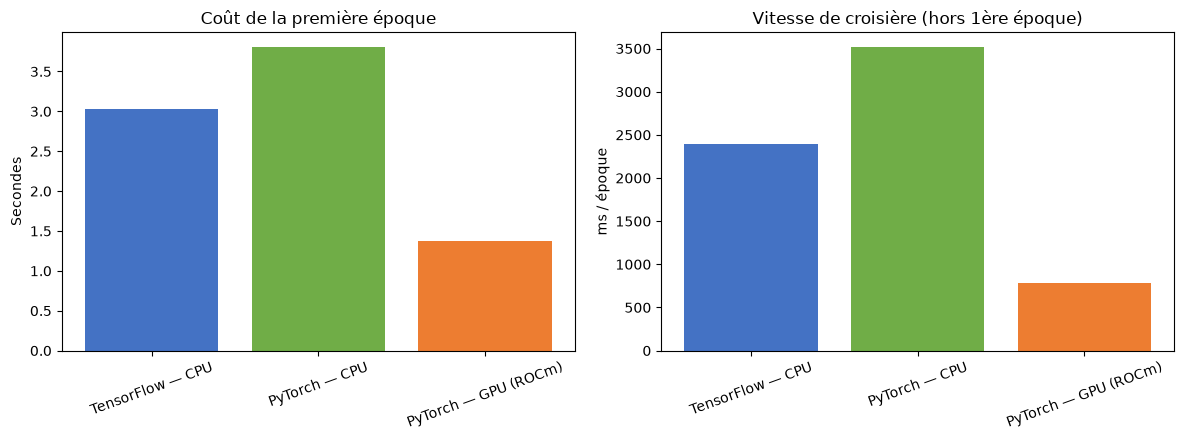

In [3]:
import matplotlib.pyplot as plt
import numpy as np

labels = list(results.keys())
first_epoch = [results[label]['first_epoch_seconds'] for label in labels]
steady_ms = [results[label]['seconds_per_epoch'] * 1000 for label in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(labels, first_epoch, color=['#4472C4', '#70AD47', '#ED7D31'])
axes[0].set_title('Coût de la première époque')
axes[0].set_ylabel('Secondes')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(labels, steady_ms, color=['#4472C4', '#70AD47', '#ED7D31'])
axes[1].set_title('Vitesse de croisière (hors 1ère époque)')
axes[1].set_ylabel('ms / époque')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Lecture du résultat précédent : que dit la vitesse mesurée ?

**PyTorch GPU vs CPU (la comparaison demandée)** : en régime de croisière, le GPU traite une époque en
**786,4 ms** contre **3512,5 ms**
sur CPU, soit **4,47x plus rapide**. Sur la première époque, l'écart est plus faible
(**2,76x**) : le GPU y paie un coût d'initialisation (compilation/mise en cache des
noyaux HIP) qui n'existe pas sur CPU — ne mesurer que quelques époques, sans isoler ce coût, aurait
sous-estimé l'avantage réel du GPU. Sur l'entraînement complet de 60 époques, le GPU
termine en **47,8 s** contre **211,0 s** sur CPU.

Point de vigilance à connaître : pour un modèle beaucoup plus petit (quelques dizaines de milliers de
paramètres) ou un jeu de données minuscule, ce même GPU peut être **plus lent** que le CPU une fois le
coût d'initialisation payé une fois pour toutes en début de session — l'avantage du GPU croît avec la
taille du modèle et des lots, il n'est pas garanti pour tout entraînement.

**Pour information (bonus, hors comparaison demandée)** : TensorFlow CPU (2390,1 ms/époque)
reste ici **1,47x plus rapide que PyTorch CPU** sur cette machine, probablement grâce
aux optimisations oneDNN/AVX-512 signalées en console pendant l'entraînement TensorFlow. Cela ne remet
pas en cause la conclusion CPU vs GPU : c'est une différence entre deux implémentations CPU, pas une
mesure de l'accélération matérielle.

In [4]:
quality_rows = [
    [
        label,
        f"{result['threshold']:.5f}",
        f"{result['roc_auc']:.4f}",
        f"{result['pr_auc']:.4f}",
        f"{result['metrics_at_threshold']['precision']:.4f}",
        f"{result['metrics_at_threshold']['recall']:.4f}",
        f"{result['metrics_at_threshold']['f1']:.4f}",
        result['metrics_at_threshold']['false_positive'],
        result['metrics_at_threshold']['false_negative'],
    ]
    for label, result in results.items()
]
print(tabulate(
    quality_rows,
    headers=['Exécution', 'Seuil', 'ROC-AUC', 'PR-AUC', 'Précision', 'Rappel', 'F1', 'FP', 'FN'],
    tablefmt='github',
))

| Exécution            |   Seuil |   ROC-AUC |   PR-AUC |   Précision |   Rappel |     F1 |   FP |   FN |
|----------------------|---------|-----------|----------|-------------|----------|--------|------|------|
| TensorFlow — CPU     | 0.00132 |    0.9605 |   0.9877 |           1 |   0.1167 | 0.209  |    0 |   53 |
| PyTorch — CPU        | 0.00106 |    0.9561 |   0.9861 |           1 |   0.1    | 0.1818 |    0 |   54 |
| PyTorch — GPU (ROCm) | 0.00101 |    0.9632 |   0.9884 |           1 |   0.1167 | 0.209  |    0 |   53 |


## Lecture du résultat précédent : la vitesse a-t-elle un coût sur la qualité ?

Non : le classement (ROC-AUC/PR-AUC) reste comparable entre CPU et GPU côté PyTorch
(ROC-AUC 0,9632 en GPU contre 0,9561 en CPU ; PR-AUC 0,9884 contre 0,9861),
et le nombre de défauts détectés au seuil choisi est identique ou supérieur (7
contre 6 sur 60).
Ces petits écarts entre CPU et GPU (même seed, même code) proviennent des implémentations numériques
différentes des noyaux de convolution selon le device, pas d'une perte de qualité liée à la vitesse —
et ils sont **parfaitement reproductibles d'une exécution à l'autre** : PyTorch, à seed fixée, produit
des poids et des métriques strictement identiques d'une ré-exécution à l'autre du même notebook, sur
CPU comme sur GPU.

**Ce n'est pas le cas de TensorFlow/Keras CPU** : sa ligne dans le tableau ci-dessus (ROC-AUC 0,9605,
seuil 0,00132) a changé par rapport à une exécution antérieure du même notebook `02a` (alors 0,9825 et
0,00138), alors que la seed, le code et la machine sont identiques — les opérations parallèles oneDNN
utilisées par TensorFlow sur CPU ne sont pas déterministes à ce niveau de précision. Une comparaison
chiffrée entre frameworks doit donc garder à l'esprit que la ligne TensorFlow peut varier d'une
exécution à l'autre, contrairement aux deux lignes PyTorch.

Les trois exécutions confirment aussi un même constat : un excellent classement (ROC-AUC > 0,95,
PR-AUC > 0,98 partout) ne se traduit pas en bonne détection au seuil `moyenne + 3 écarts-types`, trop
conservateur ici (rappel entre 0,10
et 0,12 seulement). Ce n'est pas un
défaut du framework ou du device : c'est une limite de la règle de seuil choisie, à améliorer
indépendamment (partie non traitée ici — voir
[`02e`](02e-autoencoder-pytorch-gpu-seuils.ipynb) pour une comparaison de politiques de seuil).

## Conclusion

**Sur la question posée (PyTorch CPU vs GPU)** : le GPU AMD RX 9070 XT accélère l'entraînement d'un
facteur **4,47x** en régime de croisière sur cet auto-encodeur (741 379 paramètres,
images 256×256, lots de 32), sans dégrader — et même en améliorant légèrement — la qualité de
détection. Le gain est cependant à relativiser sur la première époque (2,76x
seulement) à cause du coût d'initialisation ROCm, un coût fixe qui s'amortit d'autant mieux que
l'entraînement est long.

**Sur la comparaison bonus (TensorFlow vs PyTorch)** : les deux frameworks aboutissent à une
architecture strictement identique (même compte de paramètres) et à un comportement de reconstruction
visuellement similaire, malgré des trajectoires d'entraînement différentes (initialisations par défaut
différentes, et non-déterminisme propre à TensorFlow/Keras CPU — voir ci-dessus). TensorFlow CPU reste
ici plus rapide que PyTorch CPU sur cette machine — un résultat propre
à cette machine et cette version de TensorFlow (optimisations oneDNN), pas une règle générale.

**Limite commune aux trois exécutions**, à traiter dans une itération ultérieure : le seuil
`moyenne + 3 écarts-types` est trop conservateur pour cette catégorie — un seuil calibré différemment
(percentile de validation, ou optimisation d'un F-bêta comme dans les TP de maintenance prédictive du
sprint 2) améliorerait vraisemblablement le rappel sans changer les conclusions de vitesse ci-dessus.